# loading data

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from utils import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.dates as mdates

In [3]:
# On enlève "PythonProject/" au début
df = pd.read_csv('data/processed/dataset_complet_30min.csv')

In [4]:
df.head()

,time,Y_production,GHI_Bordeaux,DNI_Bordeaux,DHI_Bordeaux,T_Bordeaux,WS_Bordeaux,Cloud_Bordeaux,GHI_Marseille,DNI_Marseille,...,GHI_Paris,DNI_Paris,DHI_Paris,T_Paris,WS_Paris,Cloud_Paris,hour_sin,hour_cos,month_sin,month_cos
0,2018-01-01 00:00:00+00:00,-0.5,0.0,0.0,0.0,9.1,21.60,53.0,0.0,0.0,...,0.0,0.0,0.0,8.3,30.7,0.0,0.000000,1.000000,0.5,0.866025
1,2018-01-01 00:30:00+00:00,-0.5,0.0,0.0,0.0,9.2,21.10,39.5,0.0,0.0,...,0.0,0.0,0.0,8.1,30.4,29.5,0.000000,1.000000,0.5,0.866025
2,2018-01-01 01:00:00+00:00,-0.5,0.0,0.0,0.0,9.3,20.60,26.0,0.0,0.0,...,0.0,0.0,0.0,7.9,30.1,59.0,0.258819,0.965926,0.5,0.866025
3,2018-01-01 01:30:00+00:00,-0.5,0.0,0.0,0.0,9.1,20.25,61.5,0.0,0.0,...,0.0,0.0,0.0,7.9,30.0,54.0,0.258819,0.965926,0.5,0.866025
4,2018-01-01 02:00:00+00:00,-0.5,0.0,0.0,0.0,8.9,19.90,97.0,0.0,0.0,...,0.0,0.0,0.0,7.9,29.9,49.0,0.500000,0.866025,0.5,0.866025


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105155 entries, 0 to 105154
Data columns (total 36 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   time             105155 non-null  object 
 1   Y_production     105155 non-null  float64
 2   GHI_Bordeaux     105155 non-null  float64
 3   DNI_Bordeaux     105155 non-null  float64
 4   DHI_Bordeaux     105155 non-null  float64
 5   T_Bordeaux       105155 non-null  float64
 6   WS_Bordeaux      105155 non-null  float64
 7   Cloud_Bordeaux   105155 non-null  float64
 8   GHI_Marseille    105155 non-null  float64
 9   DNI_Marseille    105155 non-null  float64
 10  DHI_Marseille    105155 non-null  float64
 11  T_Marseille      105155 non-null  float64
 12  WS_Marseille     105155 non-null  float64
 13  Cloud_Marseille  105155 non-null  float64
 14  GHI_Lyon         105155 non-null  float64
 15  DNI_Lyon         105155 non-null  float64
 16  DHI_Lyon         105155 non-null  floa

# EDA

In [6]:
# Configuration pour affichage dans le notebook
%matplotlib inline

# Style scientifique
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [7]:
df.describe()

,Y_production,GHI_Bordeaux,DNI_Bordeaux,DHI_Bordeaux,T_Bordeaux,WS_Bordeaux,Cloud_Bordeaux,GHI_Marseille,DNI_Marseille,DHI_Marseille,...,GHI_Paris,DNI_Paris,DHI_Paris,T_Paris,WS_Paris,Cloud_Paris,hour_sin,hour_cos,month_sin,month_cos
count,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,...,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,105155.000000,1.051550e+05,1.051550e+05,1.051550e+05,1.051550e+05
mean,851.707470,156.596434,181.840327,57.552755,14.510989,10.816425,58.138733,187.749456,243.601236,52.191127,...,142.896981,166.578652,54.666121,12.673821,13.264429,62.028767,2.461310e-06,-1.233030e-04,-4.885167e-03,-2.210217e-03
std,1270.509811,228.716123,266.718201,78.207594,7.059454,5.595896,39.848920,262.167975,310.863053,67.619027,...,216.149304,256.250506,75.674051,7.209525,6.833862,39.249842,7.071534e-01,7.070669e-01,7.057033e-01,7.084939e-01
min,-11.500000,0.000000,0.000000,0.000000,-5.300000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-10.000000,0.000000,0.000000,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,0.000000,0.000000,0.000000,0.000000,9.500000,6.900000,15.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,7.500000,8.000000,22.000000,-7.071068e-01,-7.071068e-01,-8.660254e-01,-8.660254e-01
50%,17.000000,11.000000,3.200000,8.000000,14.000000,9.500000,68.000000,15.500000,14.250000,10.500000,...,10.000000,0.000000,8.000000,12.150000,12.000000,78.000000,1.224647e-16,-1.836970e-16,-2.449294e-16,-1.836970e-16
75%,1478.500000,264.500000,327.150000,101.000000,19.300000,13.600000,99.000000,338.000000,533.800000,98.000000,...,226.000000,275.100000,94.000000,17.800000,17.250000,100.000000,7.071068e-01,7.071068e-01,5.000000e-01,8.660254e-01
max,6697.500000,950.000000,937.400000,440.000000,40.500000,52.900000,100.000000,959.000000,952.600000,429.000000,...,915.000000,940.200000,410.000000,40.800000,50.700000,100.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [8]:
df['time'].dtype

dtype('O')

In [9]:
df['time'] = pd.to_datetime(df['time'])
df['time'].dtype

datetime64[ns, UTC]

In [10]:
df = df.sort_values('time').set_index('time')

In [11]:
# Sélection des colonnes principales pour l'affichage (Target + 1 ville témoin)
cols_to_check = ['Y_production', 'GHI_Marseille', 'T_Paris', 'WS_Bordeaux']

# Statistiques descriptives
df[cols_to_check].describe().round(2)

,Y_production,GHI_Marseille,T_Paris,WS_Bordeaux
count,105155.00,105155.00,105155.00,105155.00
mean,851.71,187.75,12.67,10.82
std,1270.51,262.17,7.21,5.60
min,-11.50,0.00,-10.00,0.00
25%,0.00,0.00,7.50,6.90
50%,17.00,15.50,12.15,9.50
75%,1478.50,338.00,17.80,13.60
max,6697.50,959.00,40.80,52.90


In [12]:
# --- DIAGNOSTIC AVANT CORRECTION ---
neg_count = (df['Y_production'] < 0).sum()
print(f"⚠️ Nombre de valeurs négatives détectées : {neg_count}")

if neg_count > 0:
    print("   Exemple de valeurs aberrantes :")
    print(df[df['Y_production'] < 0]['Y_production'].head(3))
    
    # --- CORRECTION PHYSIQUE (CLIPPING) ---
    # Projection sur l'espace admissible [0, +inf[
    # Mathématiquement : Y = max(0, Y)
    print("\n🛠️ Application de la correction physique (Clipping à 0)...")
    df['Y_production'] = df['Y_production'].clip(lower=0)
    
    # --- VÉRIFICATION ---
    print(f"✅ Nouveau minimum de production : {df['Y_production'].min()} MW")
else:
    print("✅ Aucune valeur négative trouvée.")

⚠️ Nombre de valeurs négatives détectées : 16830
   Exemple de valeurs aberrantes :
time
2018-01-01 00:00:00+00:00   -0.5
2018-01-01 00:30:00+00:00   -0.5
2018-01-01 01:00:00+00:00   -0.5
Name: Y_production, dtype: float64

🛠️ Application de la correction physique (Clipping à 0)...
✅ Nouveau minimum de production : 0.0 MW


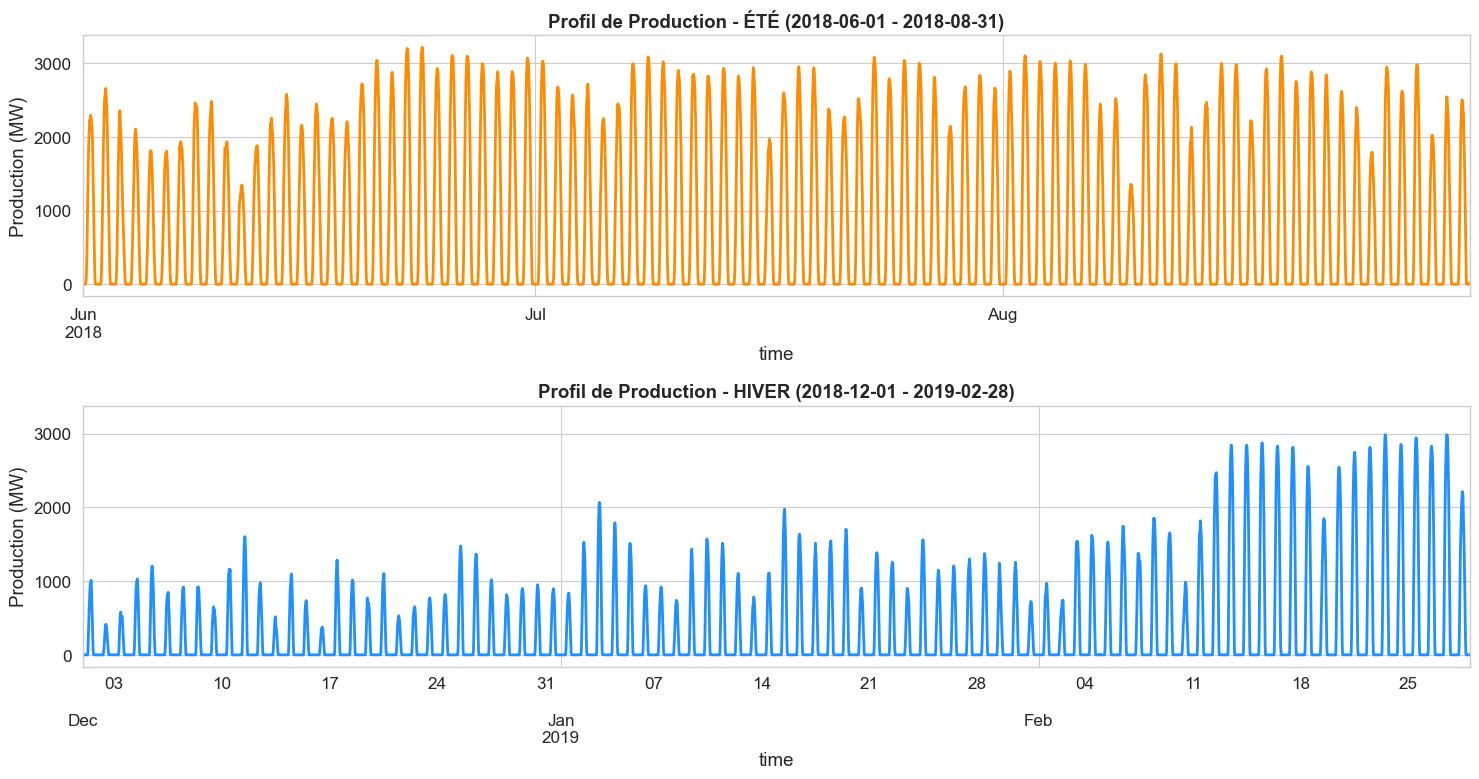

In [13]:
start_summer = '2018-06-01'
end_summer = '2018-08-31'
start_winter = '2018-12-01'
end_winter = '2019-02-28'
prod_ete_hiver(start_summer, end_summer, start_winter, end_winter, df, 'Y_production')

/Users/ishaghcheikhsidiya/projects/ProjetPython/PythonProject/utils.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df.index.hour, y='Y_production', ax=axes[0], palette="Oranges")
/Users/ishaghcheikhsidiya/projects/ProjetPython/PythonProject/utils.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df.index.month, y='Y_production', ax=axes[1], palette="Blues")


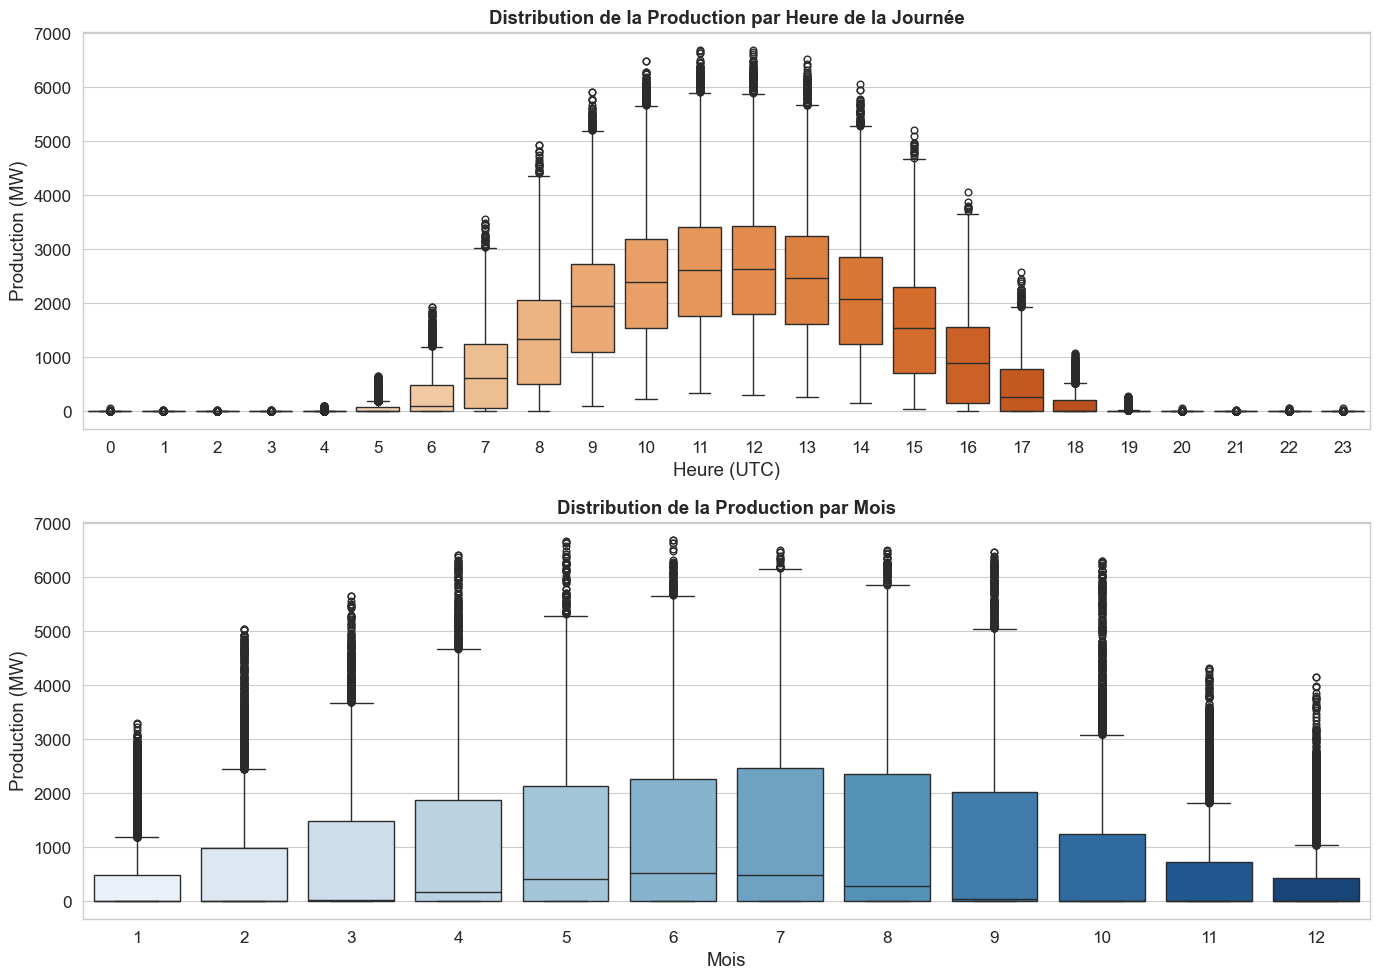

In [14]:
var_boxplot(df)

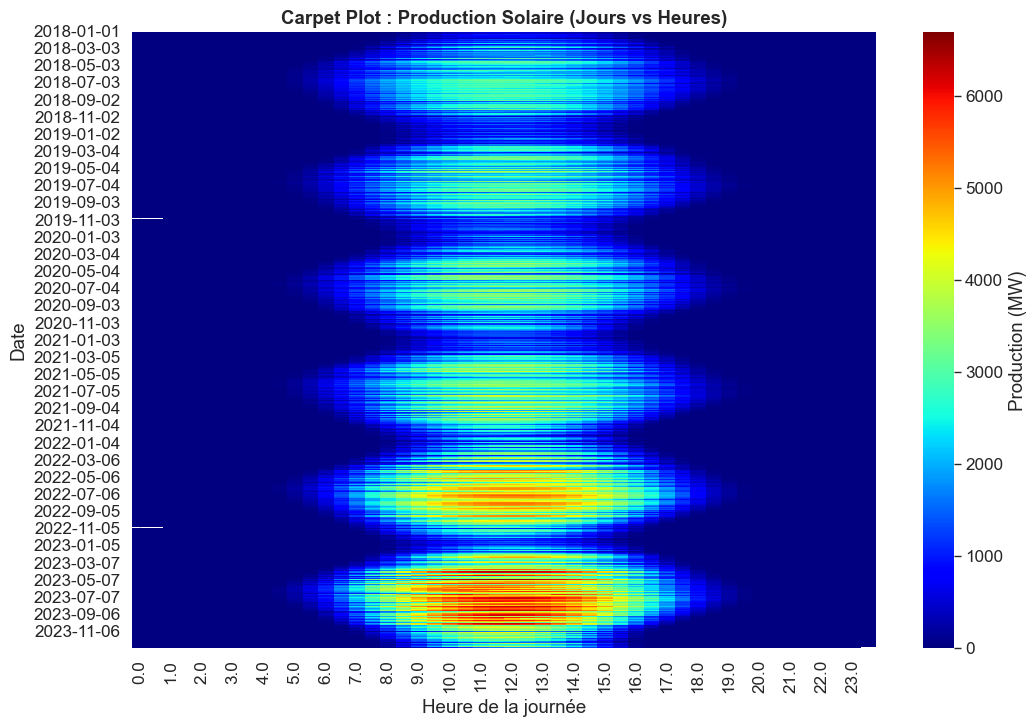

In [15]:
carpet_plot(df)

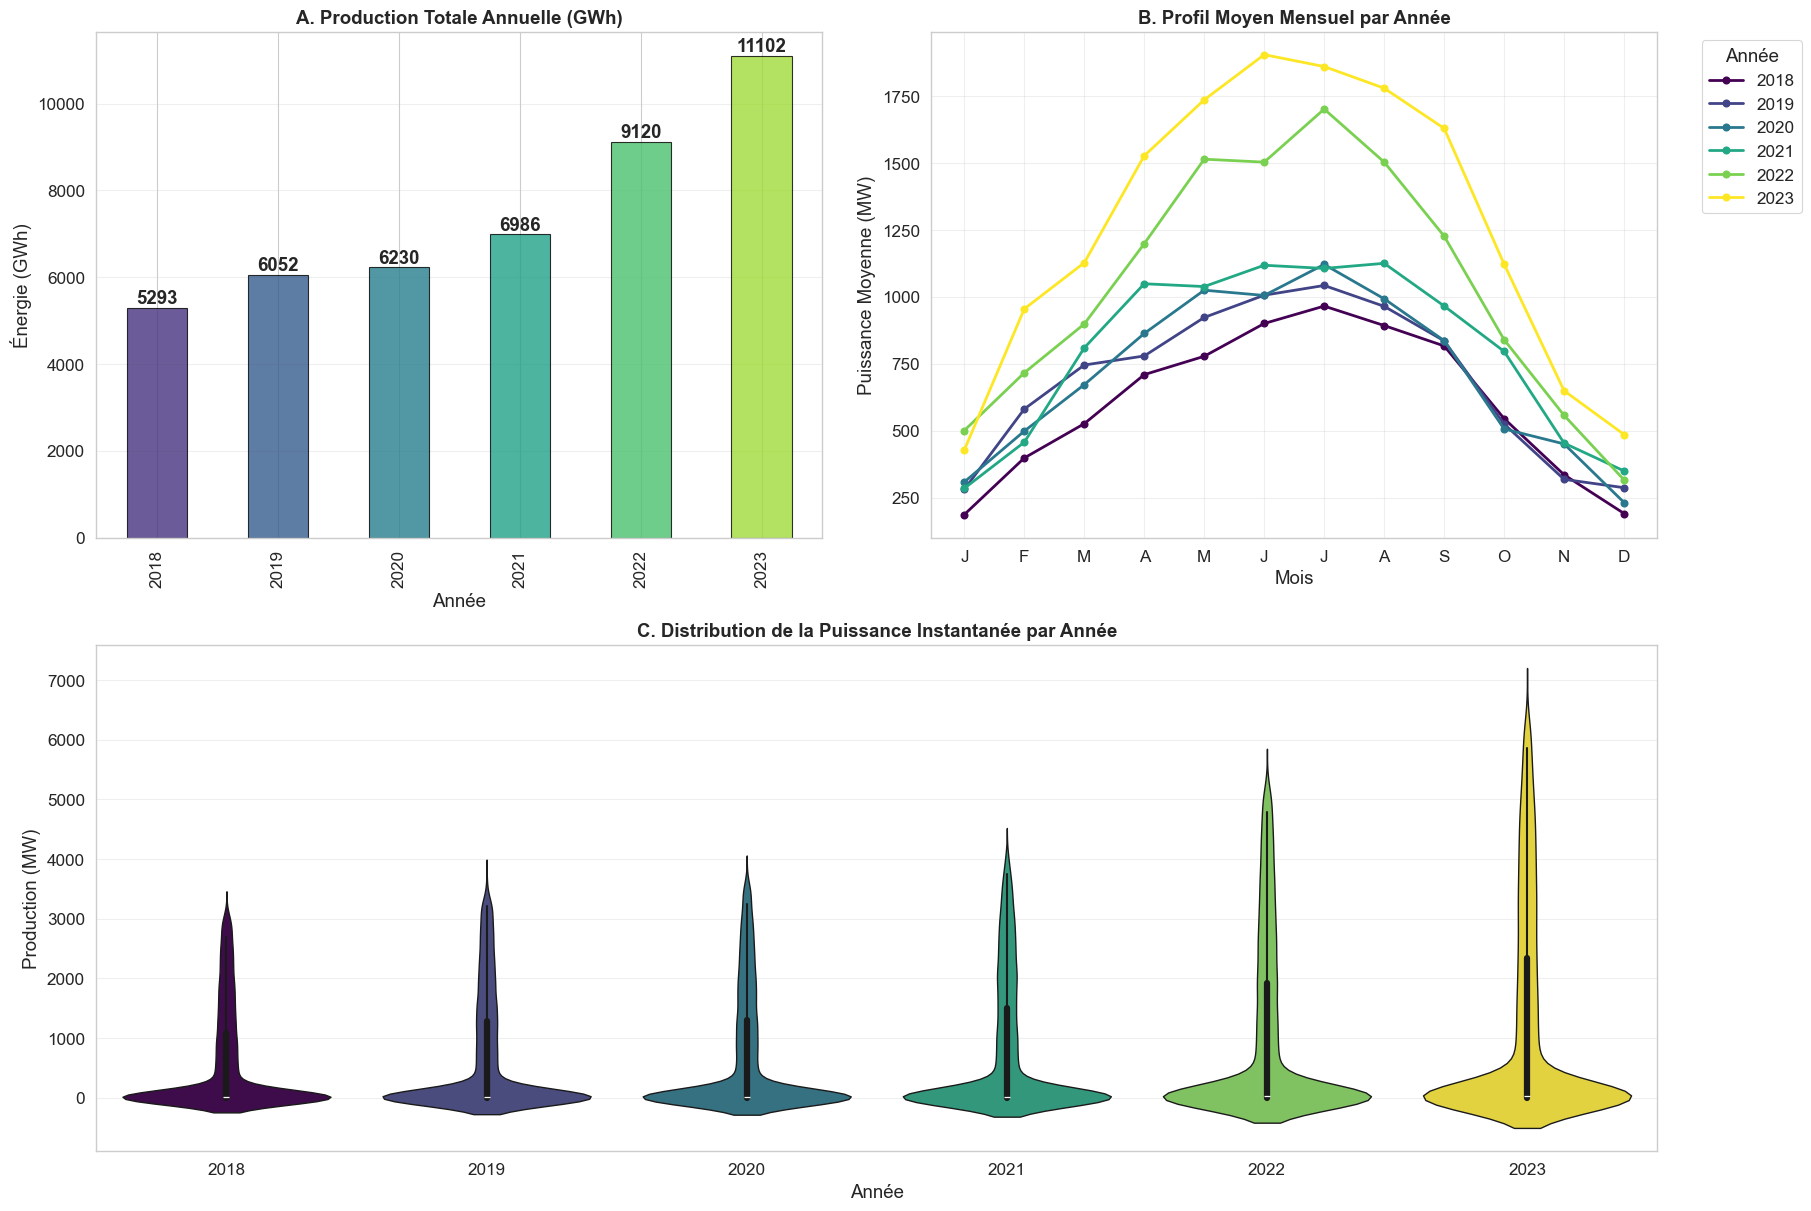

In [16]:
target_analysis(df, 'Y_production')

## Installed capacity to solve the problem of stationnarity

In [17]:

# Appel de la fonction
cap_series_api = fetch_capacity_dynamic_final()

if 'df' in locals() and not df.empty:
    print("🔄 Fusion avec le dataset principal...")
    
    # 2. Réindexation sur votre index 30 min
    df['Installed_Capacity'] = cap_series_api.reindex(df.index)
    
    # 3. Interpolation Temporelle (Time-weighted)
    # Permet de passer progressivement de la capacité 2018 à 2019
    df['Installed_Capacity'] = df['Installed_Capacity'].interpolate(method='time', limit_direction='both')
    
    # 4. Calcul du Facteur de Charge (Target 0-1)
    # On ajoute un epsilon (1e-6) pour éviter la division par zéro mathématique
    df['Y_load_factor'] = df['Y_production'] / (df['Installed_Capacity'] + 1e-6)
    
    print("✅ Dataset normalisé : Colonne 'Y_load_factor' créée.")
    print(f"   Moyenne du Load Factor : {df['Y_load_factor'].mean():.4f}")
else:
    print("⚠️ DataFrame 'df' non chargé. Lancez les cellules précédentes.")

📡 Connexion API RTE (Récupération des données)...
✅ Colonne utilisée : 'parc_installe_solaire'
✅ SUCCÈS : Données récupérées (Fin 2024 : 24349.50120499804 MW)
🔄 Fusion avec le dataset principal...
✅ Dataset normalisé : Colonne 'Y_load_factor' créée.
   Moyenne du Load Factor : 0.0718


In [18]:
df.head()

,Y_production,GHI_Bordeaux,DNI_Bordeaux,DHI_Bordeaux,T_Bordeaux,WS_Bordeaux,Cloud_Bordeaux,GHI_Marseille,DNI_Marseille,DHI_Marseille,...,DHI_Paris,T_Paris,WS_Paris,Cloud_Paris,hour_sin,hour_cos,month_sin,month_cos,Installed_Capacity,Y_load_factor
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,9.1,21.60,53.0,0.0,0.0,0.0,...,0.0,8.3,30.7,0.0,0.000000,1.000000,0.5,0.866025,8556.977987,0.0
2018-01-01 00:30:00+00:00,0.0,0.0,0.0,0.0,9.2,21.10,39.5,0.0,0.0,0.0,...,0.0,8.1,30.4,29.5,0.000000,1.000000,0.5,0.866025,8556.977987,0.0
2018-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,9.3,20.60,26.0,0.0,0.0,0.0,...,0.0,7.9,30.1,59.0,0.258819,0.965926,0.5,0.866025,8556.977987,0.0
2018-01-01 01:30:00+00:00,0.0,0.0,0.0,0.0,9.1,20.25,61.5,0.0,0.0,0.0,...,0.0,7.9,30.0,54.0,0.258819,0.965926,0.5,0.866025,8556.977987,0.0
2018-01-01 02:00:00+00:00,0.0,0.0,0.0,0.0,8.9,19.90,97.0,0.0,0.0,0.0,...,0.0,7.9,29.9,49.0,0.500000,0.866025,0.5,0.866025,8556.977987,0.0


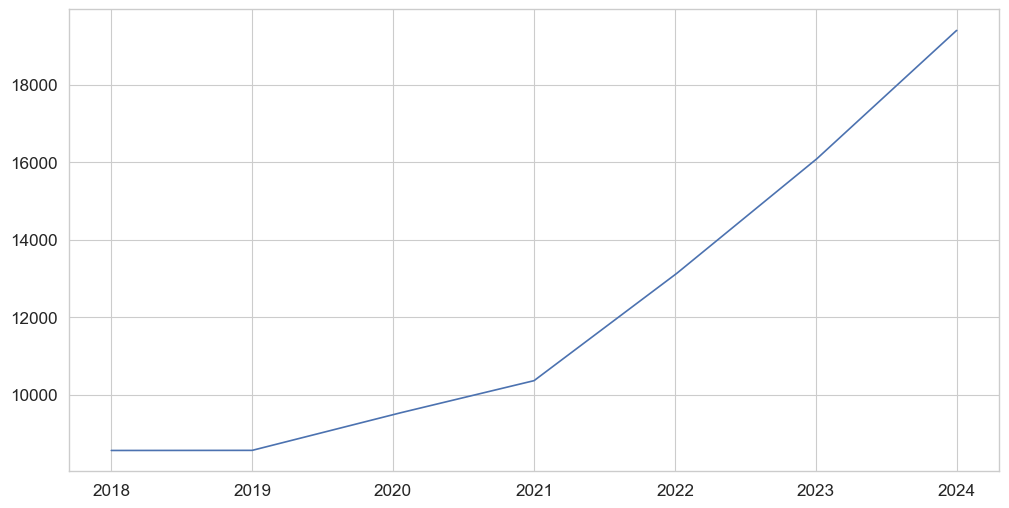

In [19]:
plt.plot(df["Installed_Capacity"])

In [20]:
df['Y_load_factor'].describe().round(4)

count    105155.0000
mean          0.0718
std           0.1019
min           0.0000
25%           0.0000
50%           0.0015
75%           0.1321
max           0.4177
Name: Y_load_factor, dtype: float64

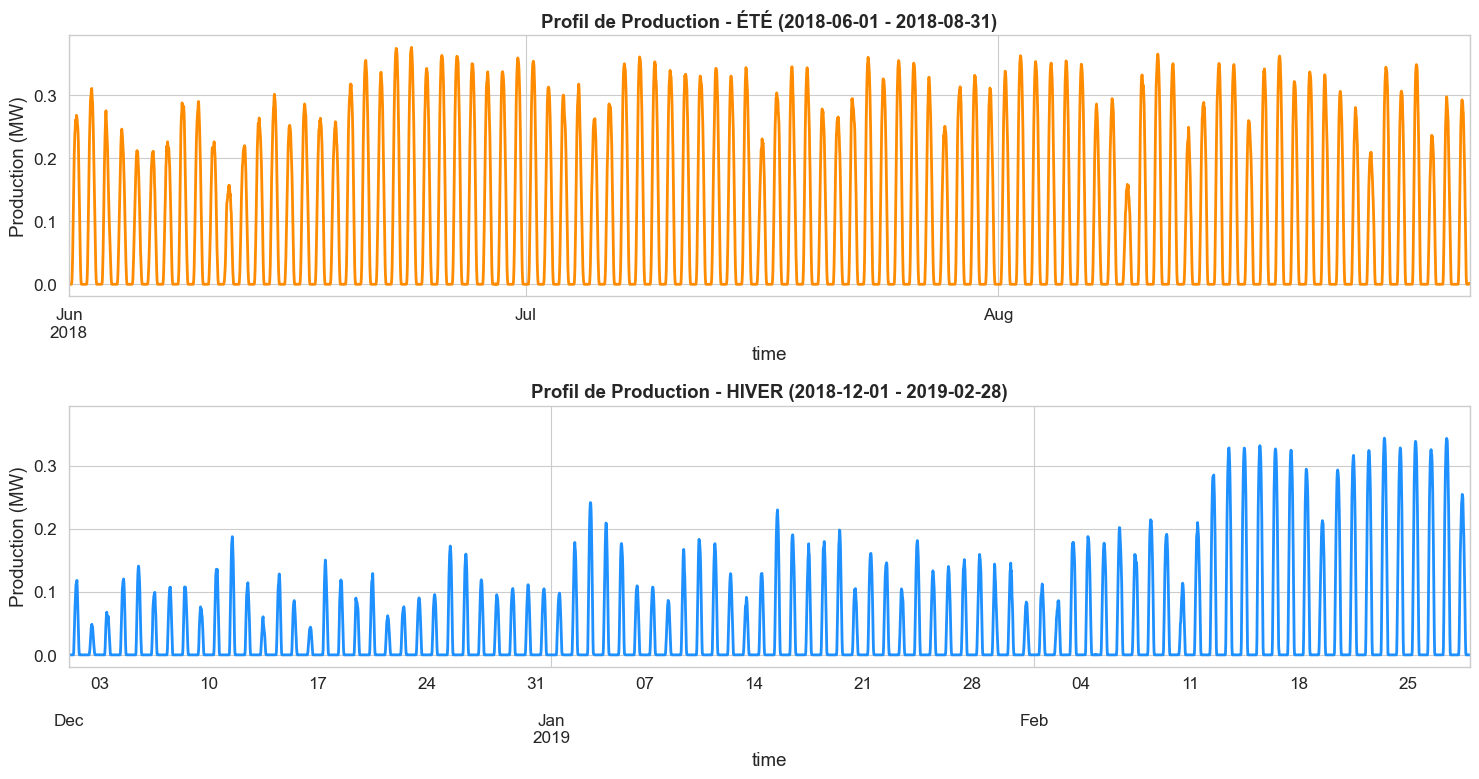

In [21]:
start_summer = '2018-06-01'
end_summer = '2018-08-31'
start_winter = '2018-12-01'
end_winter = '2019-02-28'
prod_ete_hiver(start_summer, end_summer, start_winter, end_winter, df, 'Y_load_factor')


2. Analyse du Facteur de Charge (%)


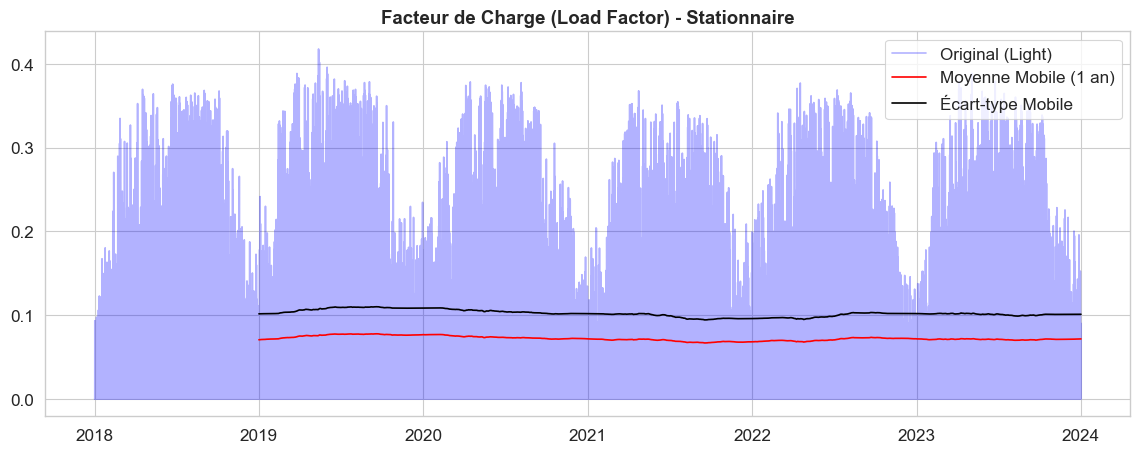

--- Résultats du Test ADF pour : Facteur de Charge (Load Factor) - Stationnaire ---
Test Statistic                -1.172248e+01
p-value                        1.402658e-21
#Lags Used                     6.100000e+01
Number of Observations Used    1.050930e+05
Critical Value (1%)           -3.430412e+00
Critical Value (5%)           -2.861568e+00
Critical Value (10%)          -2.566785e+00
dtype: float64
✅ CONCLUSION : La série est STATIONNAIRE (H0 rejetée).
--------------------------------------------------


In [22]:
print("\n2. Analyse du Facteur de Charge (%)")
test_stationarity(df['Y_load_factor'], title="Facteur de Charge (Load Factor) - Stationnaire")


## Analyse des var explicatives

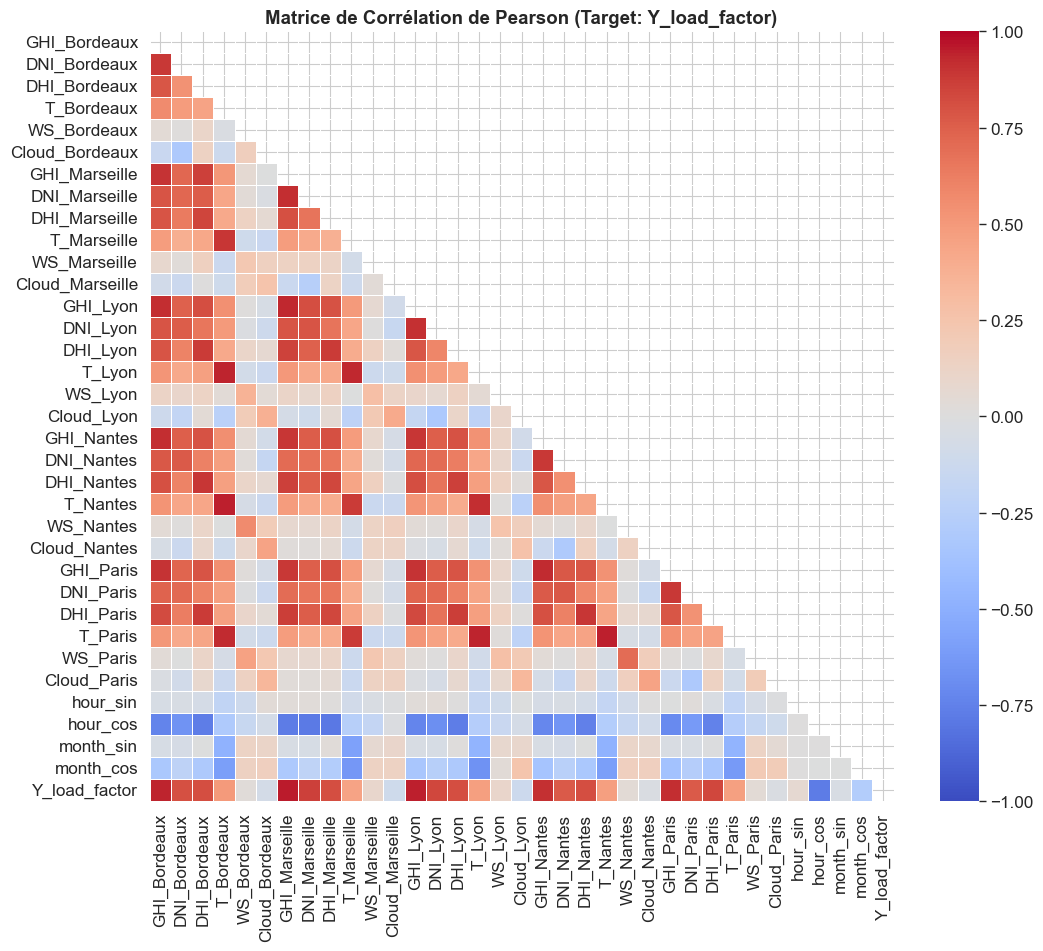

--- Top Corrélations avec Y_load_factor ---
Y_load_factor      1.000000
GHI_Marseille      0.954198
GHI_Lyon           0.949848
GHI_Bordeaux       0.941184
GHI_Paris          0.915403
GHI_Nantes         0.911705
DNI_Marseille      0.860539
DNI_Lyon           0.840461
DHI_Paris          0.836357
DHI_Nantes         0.820035
DHI_Lyon           0.819278
DHI_Bordeaux       0.816333
DHI_Marseille      0.814770
DNI_Bordeaux       0.804787
DNI_Nantes         0.771690
DNI_Paris          0.766961
T_Bordeaux         0.499927
T_Lyon             0.475653
T_Nantes           0.474791
T_Paris            0.463579
T_Marseille        0.451857
WS_Lyon            0.100639
WS_Marseille       0.091451
hour_sin           0.066391
WS_Paris           0.046095
WS_Nantes          0.044233
WS_Bordeaux        0.024251
Cloud_Paris       -0.026817
Cloud_Nantes      -0.031077
month_sin         -0.044404
Cloud_Bordeaux    -0.074398
Cloud_Marseille   -0.106120
Cloud_Lyon        -0.117554
month_cos         -0.280225
hour

In [23]:
plot_correlation_matrix(df)

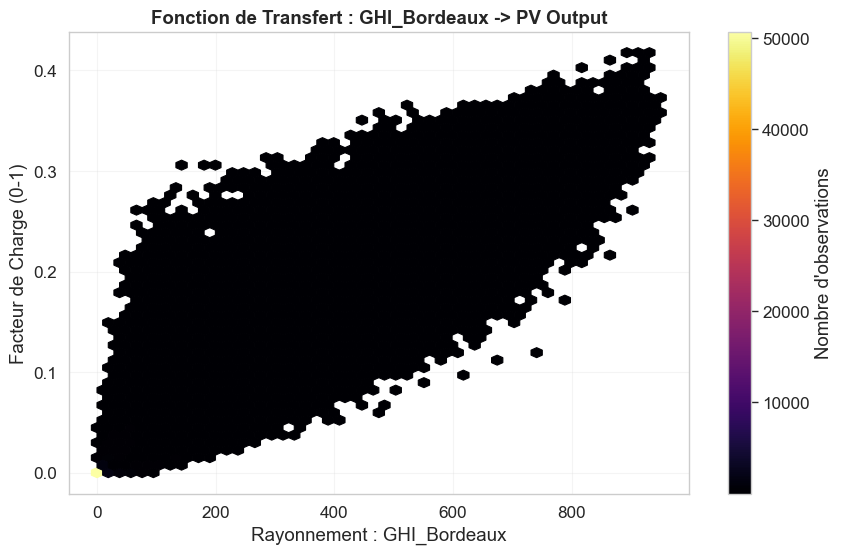

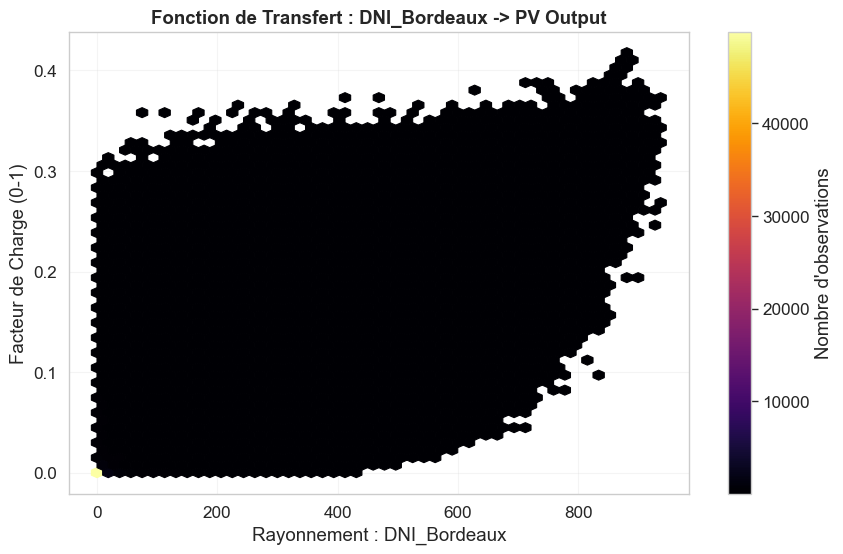

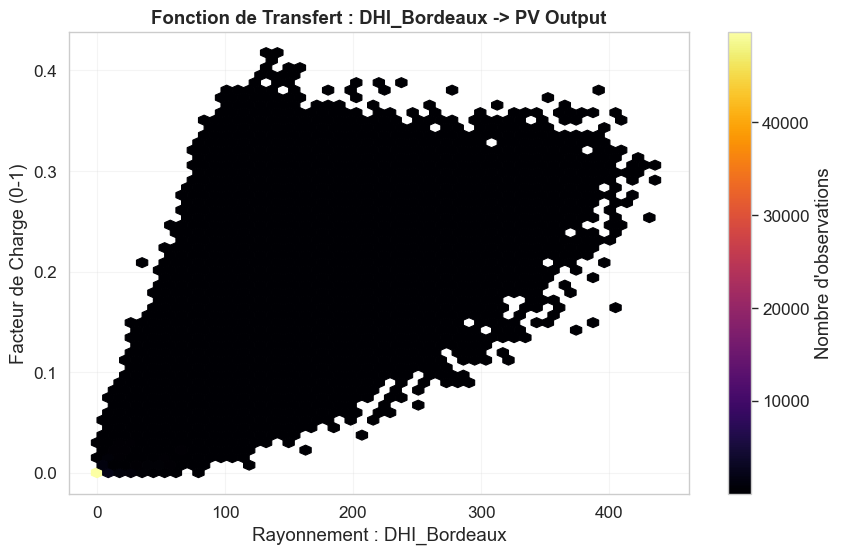

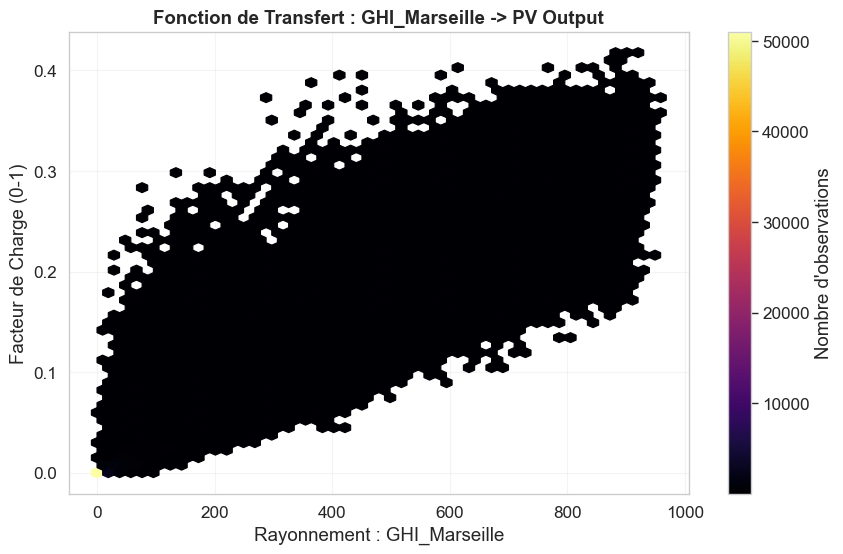

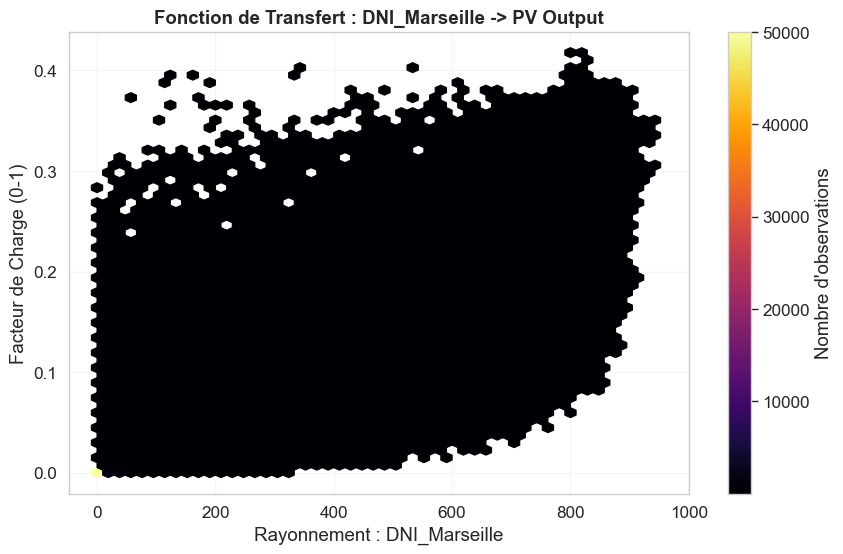

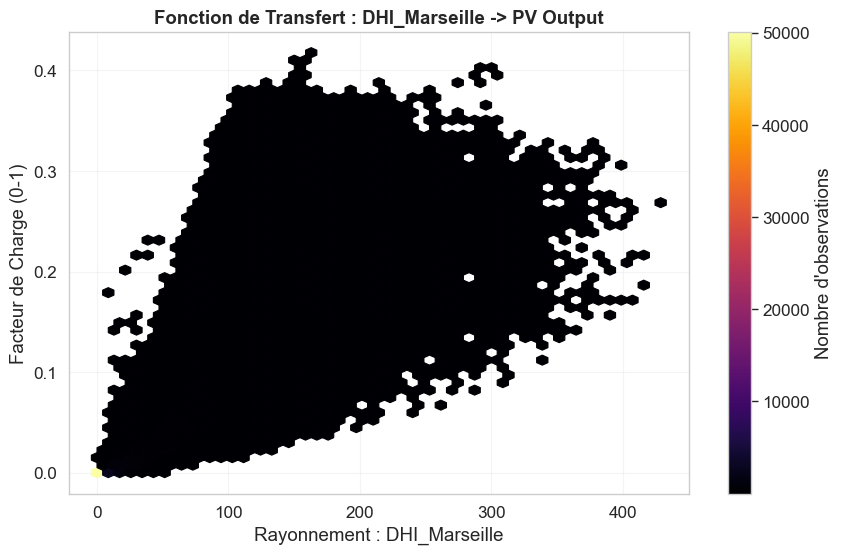

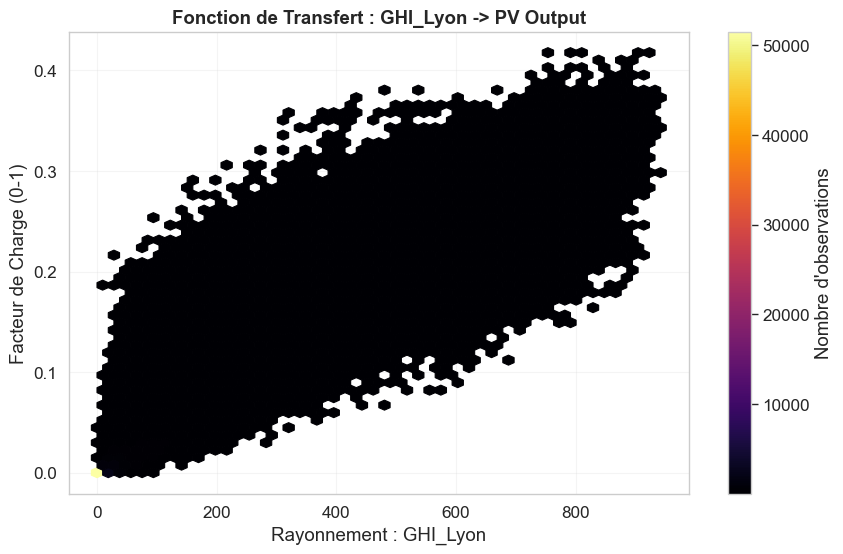

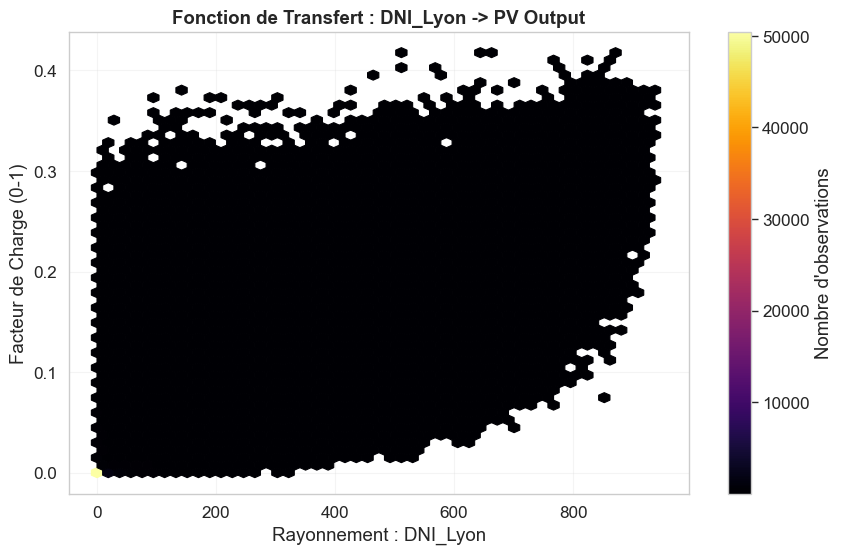

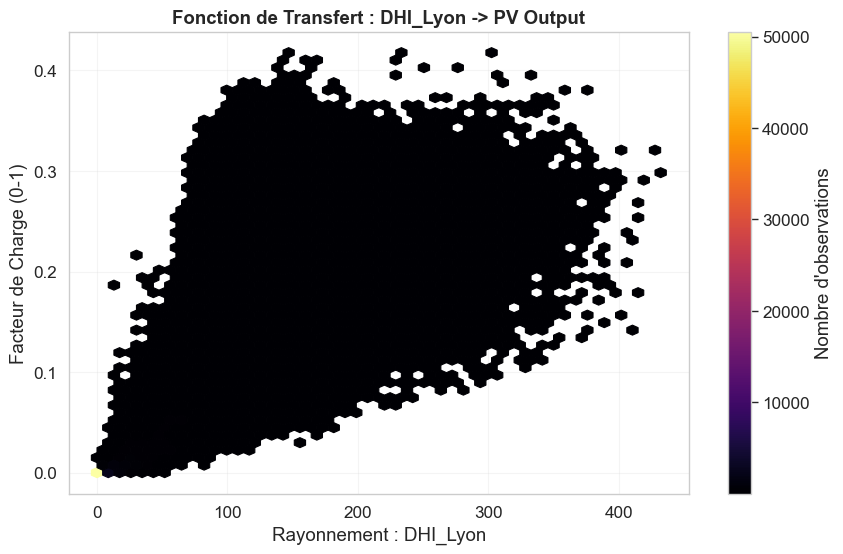

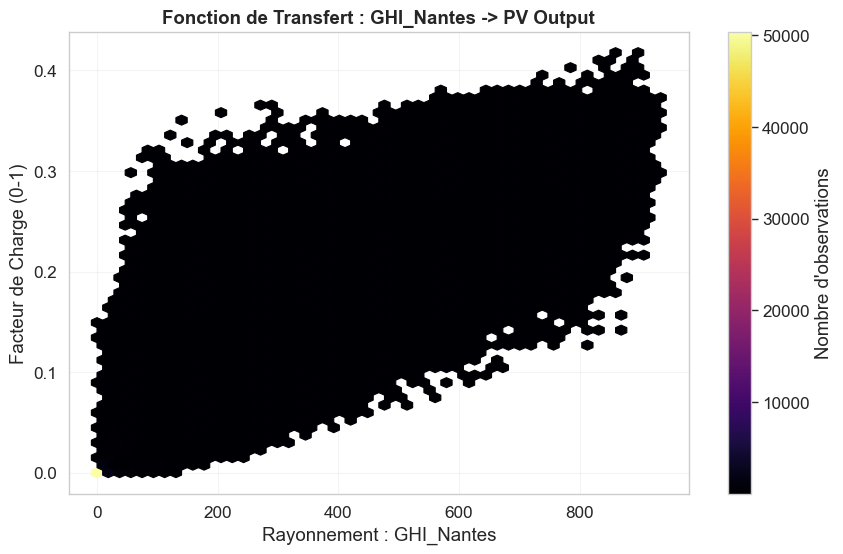

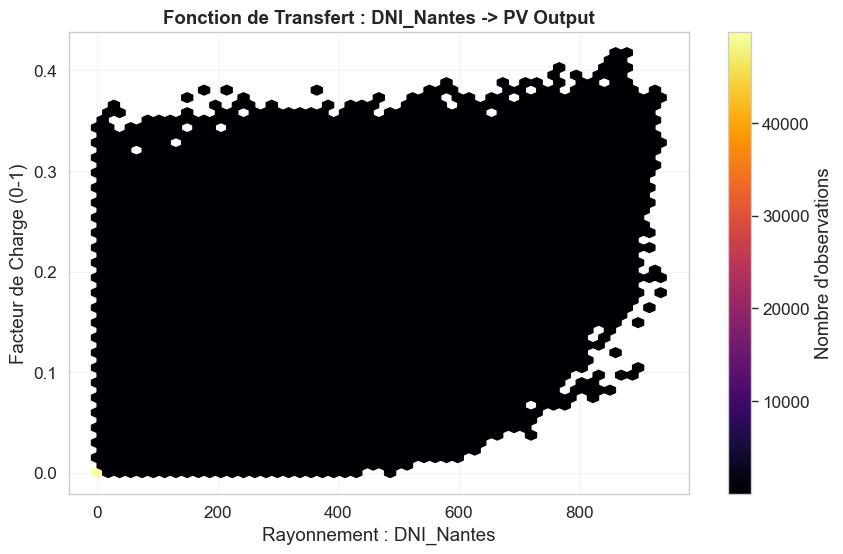

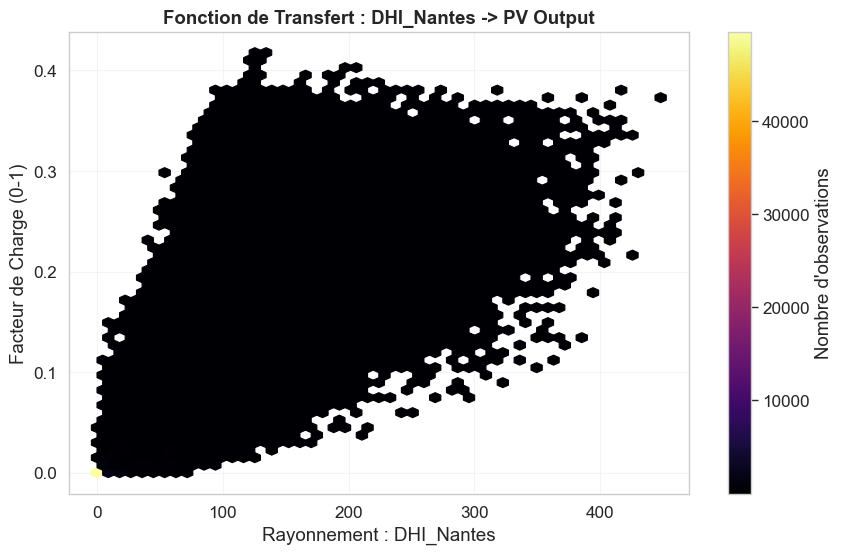

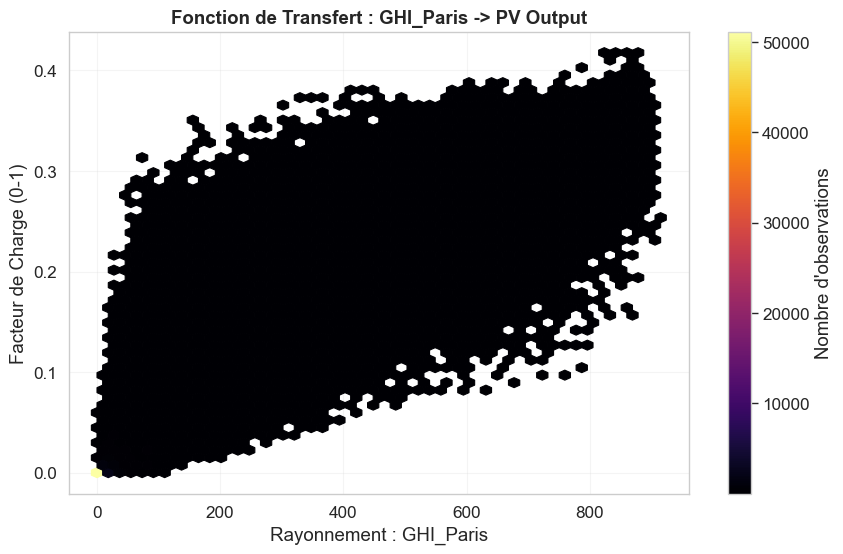

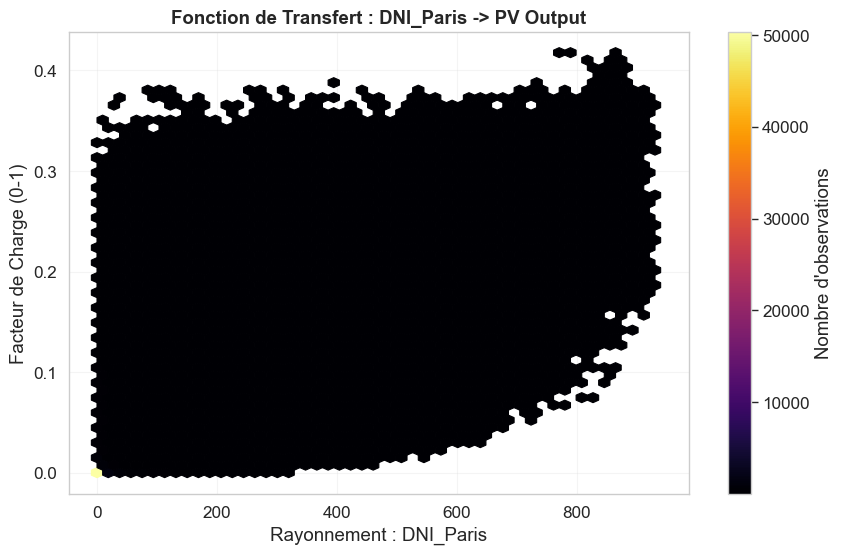

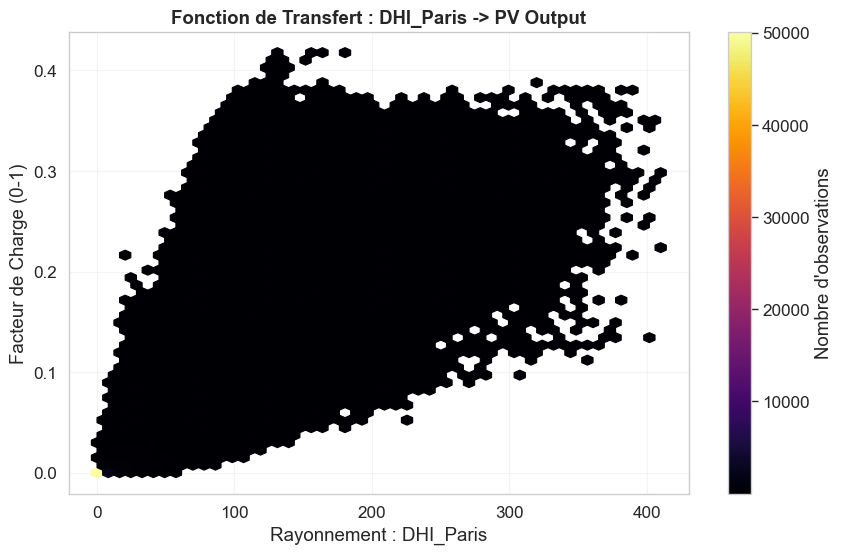

In [24]:

# Exemple hypothétique, changez le nom de la variable X
rad_cols = [c for c in df.columns if 'dni' in c.lower() or 'dhi' in c.lower() or 'ghi' in c.lower()]
if rad_cols:
        for col in rad_cols:
            plot_radiation_dependency(df, rad_col=col)
else:
        print("⚠️ Trouvez le nom de votre colonne 'Rayonnement' dans df.columns")   

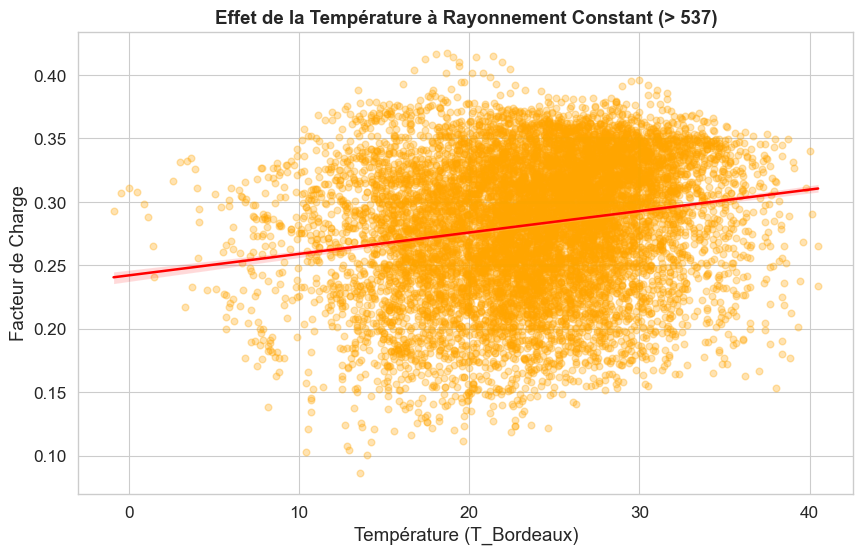

📉 Corrélation à haute irradiance : 0.187
⚠️ Pas d'effet thermique visible (ou données biaisées).


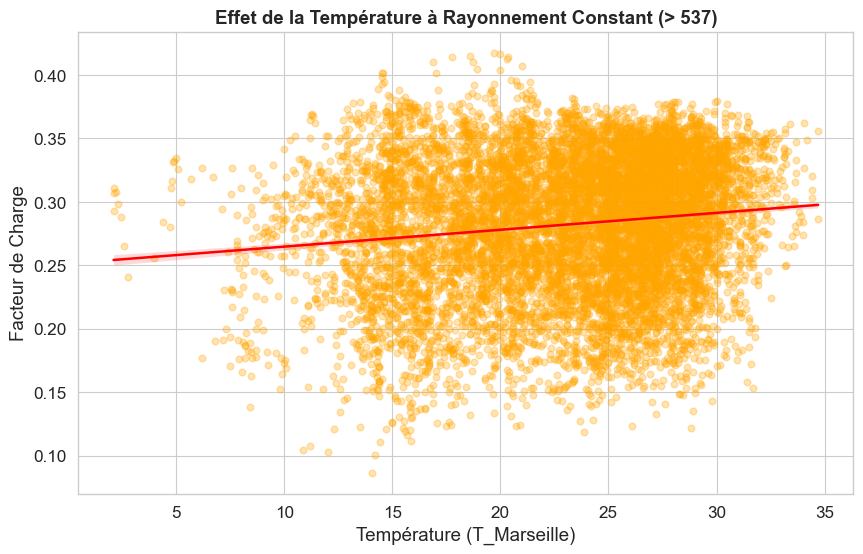

📉 Corrélation à haute irradiance : 0.135
⚠️ Pas d'effet thermique visible (ou données biaisées).


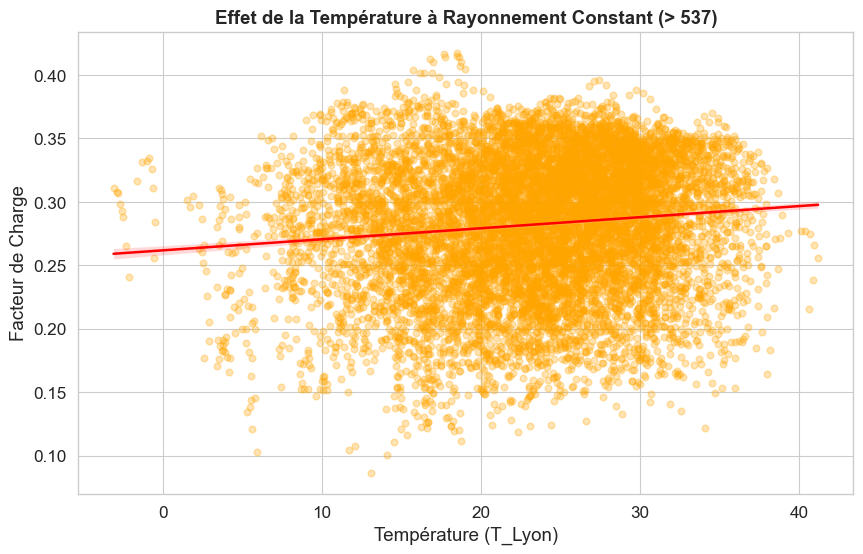

📉 Corrélation à haute irradiance : 0.112
⚠️ Pas d'effet thermique visible (ou données biaisées).


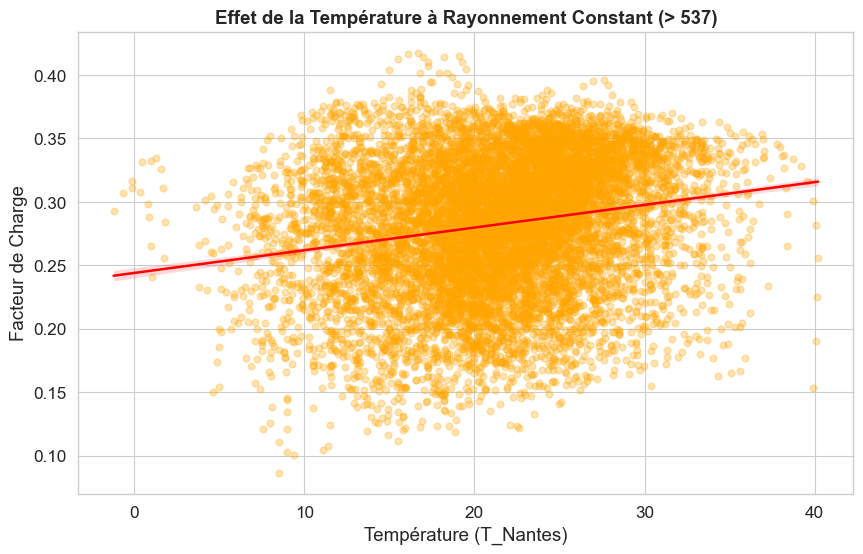

📉 Corrélation à haute irradiance : 0.195
⚠️ Pas d'effet thermique visible (ou données biaisées).


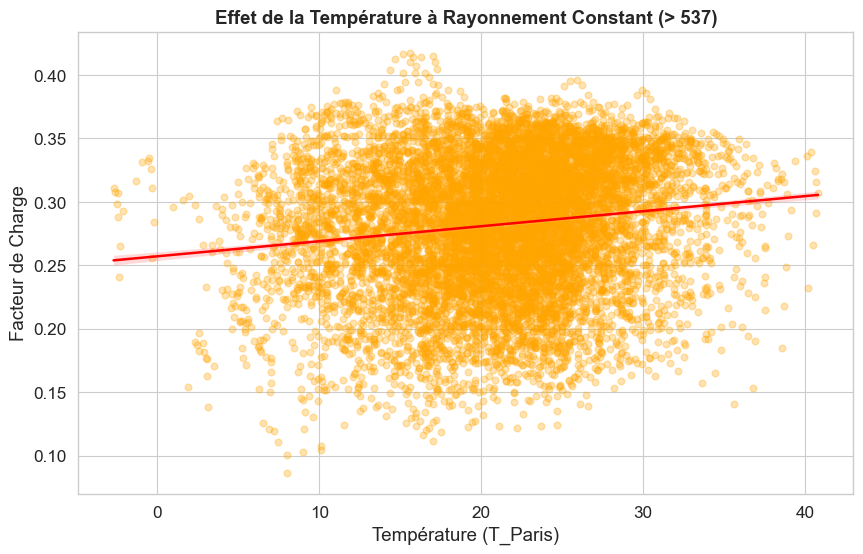

📉 Corrélation à haute irradiance : 0.139
⚠️ Pas d'effet thermique visible (ou données biaisées).


In [25]:
# Adaptez les noms de colonnes (t2m = temp à 2m souvent)
if 'df' in locals() and rad_cols:
    temp_cols = [c for c in df.columns if 'T' in c]
    
    if temp_cols:
        for col in temp_cols:
            plot_temperature_effect(df, temp_col=col, rad_col=rad_cols[0])

# Training 

In [ ]:
# splitting the data into train and test sets
import statsmodels.api as sm

In [59]:
date_coupure = '2023-01-01'

x_train = df.drop(columns=['Y_load_factor', 'Y_production', 'Installed_Capacity']).loc[:date_coupure]
y_train = df['Y_load_factor'].loc[:date_coupure]

x_test = df.drop(columns=['Y_load_factor', 'Y_production', 'Installed_Capacity']).loc[date_coupure:]
y_test = df['Y_load_factor'].loc[date_coupure:]

In [60]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 87686 entries, 2018-01-01 00:00:00+00:00 to 2023-01-01 23:30:00+00:00
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GHI_Bordeaux     87686 non-null  float64
 1   DNI_Bordeaux     87686 non-null  float64
 2   DHI_Bordeaux     87686 non-null  float64
 3   T_Bordeaux       87686 non-null  float64
 4   WS_Bordeaux      87686 non-null  float64
 5   Cloud_Bordeaux   87686 non-null  float64
 6   GHI_Marseille    87686 non-null  float64
 7   DNI_Marseille    87686 non-null  float64
 8   DHI_Marseille    87686 non-null  float64
 9   T_Marseille      87686 non-null  float64
 10  WS_Marseille     87686 non-null  float64
 11  Cloud_Marseille  87686 non-null  float64
 12  GHI_Lyon         87686 non-null  float64
 13  DNI_Lyon         87686 non-null  float64
 14  DHI_Lyon         87686 non-null  float64
 15  T_Lyon           87686 non-null  float64
 16  WS_Lyon    

In [61]:
y_train.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 87686 entries, 2018-01-01 00:00:00+00:00 to 2023-01-01 23:30:00+00:00
Series name: Y_load_factor
Non-Null Count  Dtype  
--------------  -----  
87686 non-null  float64
dtypes: float64(1)
memory usage: 1.3 MB


### Linear regression

In [62]:
# linear regression model
X_train_sm = sm.add_constant(x_train)
model = sm.OLS(y_train , X_train_sm).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Y_load_factor   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                 7.346e+04
Date:                Sat, 27 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:01:51   Log-Likelihood:             2.2409e+05
No. Observations:               87686   AIC:                        -4.481e+05
Df Residuals:                   87651   BIC:                        -4.478e+05
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0040      0.000      8.650      0.000       0.003       0.005
GHI_Bordeaux     9.912e-05   2.21e-06     44.749      0.000    9.48e-05       0.000
DNI_Bordeaux     1.555e-05   1.27e-06     12.255      0.000    1.31e-05     1.8e-05
DHI_Bordeaux    -2.691e-05    2.8e-06     -9.625      0.000   -3.24e-05   -2.14e-05
T_Bordeaux          0.0002   3.89e-05      5.294      0.000       0.000       0.000
WS_Bordeaux        -0.0003    1.5e-05    -20.410      0.000      -0.000      -0.000
Cloud_Bordeaux  -1.006e-05   2.22e-06     -4.527      0.000   -1.44e-05   -5.71e-06
GHI_Marseille       0.0002   2.03e-06     86.082      0.000       0.000       0.000
DNI_Marseille   -1.394e-05   1.08e-06    -12.905      0.000   -1.61e-05   -1.18e-05
DHI_Marseille    2.493e-05   2.77e-06      8.996      0.000    1.95e-05    3.04e-05
T_Marseille         0.0008   3.45e-05     24.132      0.000       0.001       0.001
WS_Marseille       -0.0001   7.24e-06    -14.739      0.000      -0.000   -9.25e-05
Cloud_Marseille -9.389e-06   2.04e-06     -4.613      0.000   -1.34e-05    -5.4e-06
GHI_Lyon            0.0001   2.31e-06     52.053      0.000       0.000       0.000
DNI_Lyon        -6.147e-06   1.28e-06     -4.821      0.000   -8.65e-06   -3.65e-06
DHI_Lyon         1.305e-05   2.88e-06      4.533      0.000    7.41e-06    1.87e-05
T_Lyon             -0.0014   3.49e-05    -39.841      0.000      -0.001      -0.001
WS_Lyon             0.0001   1.03e-05      9.976      0.000    8.26e-05       0.000
Cloud_Lyon        -2.6e-05   2.24e-06    -11.602      0.000   -3.04e-05   -2.16e-05
GHI_Nantes      -2.393e-05   2.25e-06    -10.628      0.000   -2.83e-05   -1.95e-05
DNI_Nantes       2.999e-05   1.26e-06     23.761      0.000    2.75e-05    3.25e-05
DHI_Nantes        6.62e-06   2.85e-06      2.319      0.020    1.03e-06    1.22e-05
T_Nantes        -3.971e-05   4.38e-05     -0.907      0.365      -0.000    4.61e-05
WS_Nantes         -7.6e-05   1.44e-05     -5.264      0.000      -0.000   -4.77e-05
Cloud_Nantes     8.749e-06   2.23e-06      3.917      0.000    4.37e-06    1.31e-05
GHI_Paris         1.65e-05   2.29e-06      7.192      0.000     1.2e-05     2.1e-05
DNI_Paris        2.079e-05   1.25e-06     16.630      0.000    1.83e-05    2.32e-05
DHI_Paris        6.993e-06   2.83e-06      2.475      0.013    1.46e-06    1.25e-05
T_Paris          6.672e-05   3.63e-05      1.838      0.066   -4.42e-06       0.000
WS_Paris            0.0002   1.39e-05     11.101      0.000       0.000       0.000
Cloud_Paris      1.884e-06   2.23e-06      0.846      0.398   -2.48e-06    6.25e-06
hour_sin            0.0073      0.000     69.780      0.000       0.007       0.007
hour_cos           -0.0017      0.000     -7.828      0.000      -0.002      -0.001
month_sin          -0.0016      0.000    -10.026      0.000

=== Variance Inflation Factor (VIF) ===
            Feature         VIF
12         GHI_Lyon  109.556229
6     GHI_Marseille  104.935385
21         T_Nantes  103.057462
3        T_Bordeaux   96.784917
0      GHI_Bordeaux   93.458625
18       GHI_Nantes   92.178562
24        GHI_Paris   88.023889
15           T_Lyon   73.222530
27          T_Paris   68.629146
9       T_Marseille   54.528087
13         DNI_Lyon   47.293251
7     DNI_Marseille   44.694394
1      DNI_Bordeaux   41.999739
19       DNI_Nantes   40.396129
25        DNI_Paris   36.584676
20       DHI_Nantes   17.933352
2      DHI_Bordeaux   17.851844
26        DHI_Paris   17.064886
14         DHI_Lyon   16.484159
8     DHI_Marseille   13.891802
22        WS_Nantes   12.230398
28         WS_Paris   10.312218
4       WS_Bordeaux    8.206632
29      Cloud_Paris    6.361010
23     Cloud_Nantes    6.237806
5    Cloud_Bordeaux    5.975094
17       Cloud_Lyon    5.746610
31         hour_cos    4.952240
16          WS_Lyon    4.564661


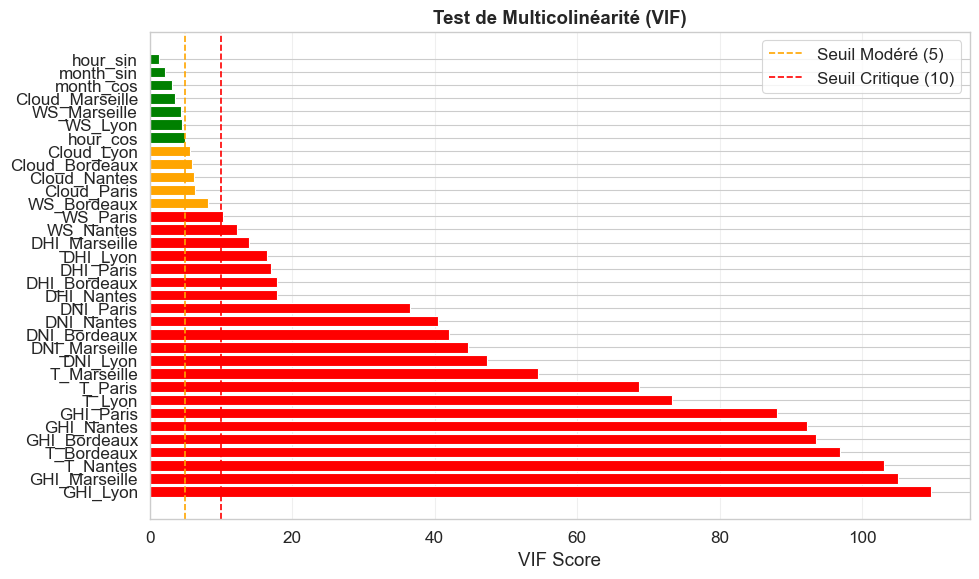

In [63]:
plot_vif(x_train)


=== Modèles de Régression avec Pénalisation ===

📊 Ridge (L2)
   Features actives: 34/34

📊 Lasso (L1)
   Features actives: 13/34

📊 ElasticNet
   Features actives: 18/34


=== Comparaison des Modèles ===
     Model  R² Train  Non-zero coefs
Ridge (L2)  0.966095              34
Lasso (L1)  0.964302              13
ElasticNet  0.965152              18


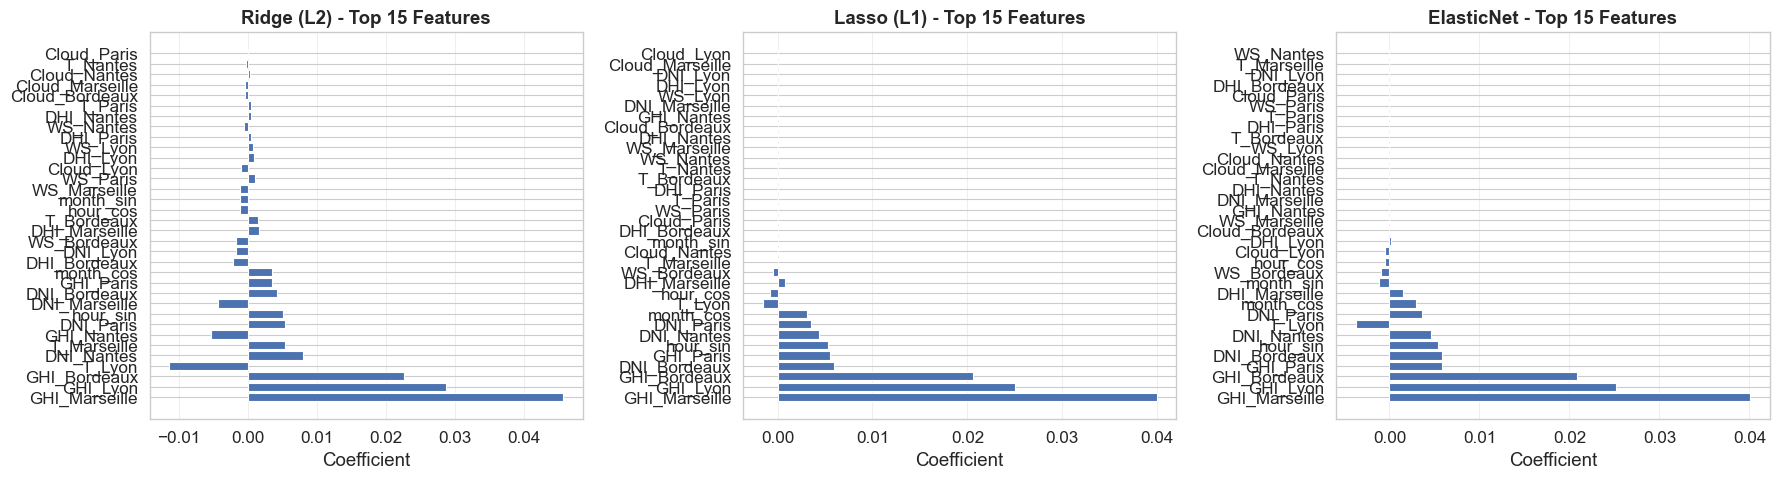

In [64]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Standardize features (important for regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)


# Dictionary to store models and results
models = {
    'Ridge (L2)': Ridge(alpha=1.0, random_state=42),
    'Lasso (L1)': Lasso(alpha=0.001, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=10000)
}

results = []

print("=== Modèles de Régression avec Pénalisation ===\n")

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train_scaled)
    
    
    # Metrics
    r2_train = r2_score(y_train, y_pred_train)
    
    
    
    
    results.append({
        'Model': name,
        'R² Train': r2_train,
        
        'Non-zero coefs': np.sum(model.coef_ != 0)
    })
    
    print(f"📊 {name}")
   
    print(f"   Features actives: {np.sum(model.coef_ != 0)}/{len(model.coef_)}\n")

# Results DataFrame
results_df = pd.DataFrame(results)
print("\n=== Comparaison des Modèles ===")
print(results_df.to_string(index=False))

# Visualization: Coefficients comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    coef_df = pd.DataFrame({
        'Feature': x_train.columns,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    axes[idx].barh(coef_df['Feature'], coef_df['Coefficient'])
    axes[idx].set_title(f'{name} - Top 15 Features', fontweight='bold')
    axes[idx].set_xlabel('Coefficient')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### PCA

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition  import PCA

In [66]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)
feature_names = x_train.columns

In [67]:
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

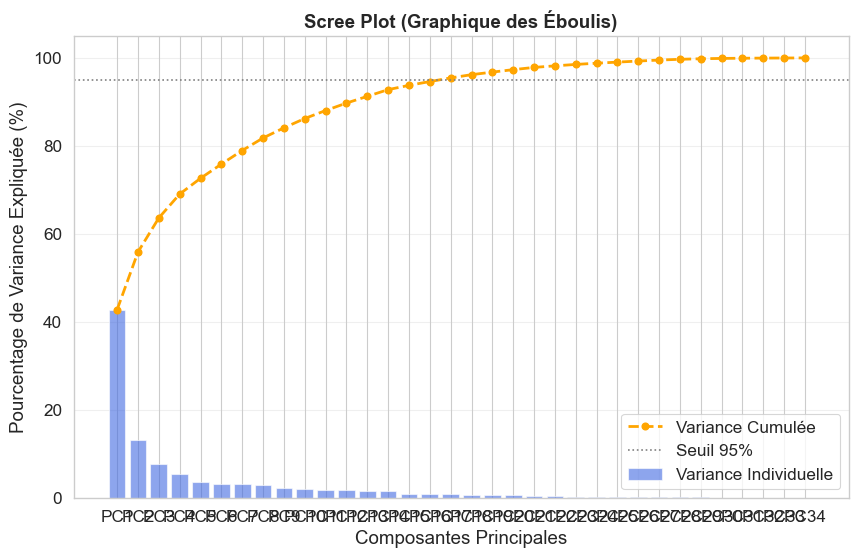

In [68]:
plot_scree_plot(pca)

Optimisation du placement des labels en cours...


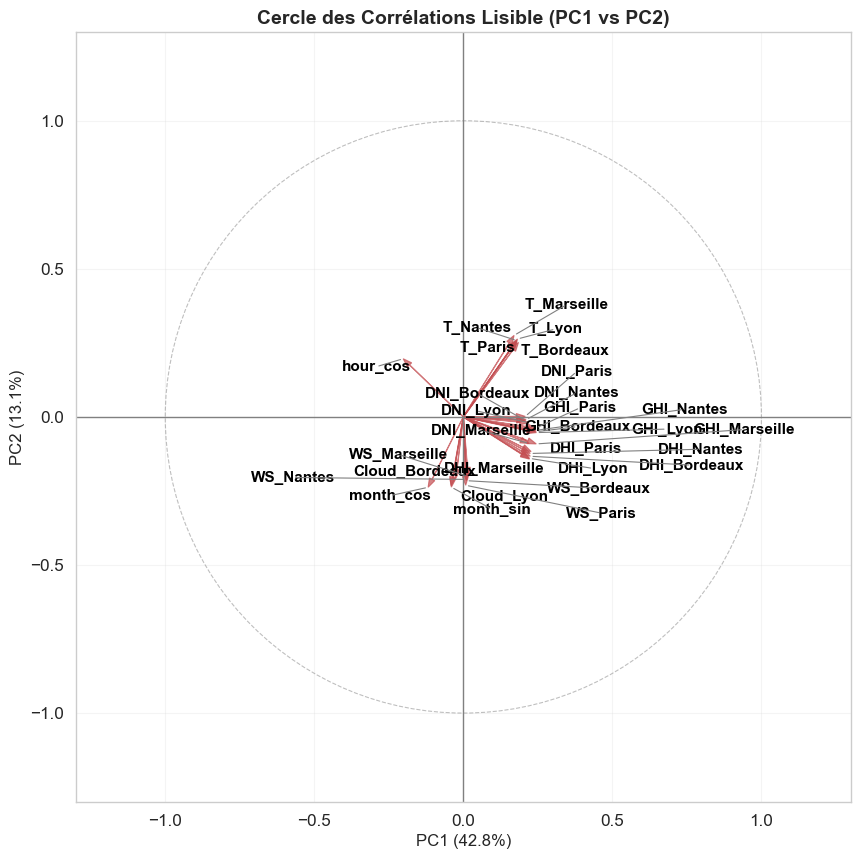

In [69]:
plot_correlation_circle_readable(pca, feature_names)


In [70]:
# Dimensionality reduction to 2 components
pca = PCA(n_components = 2)


In [71]:
pca.fit(x_scaled)
x_pca = pca.transform(x_scaled)
# training on x_pca
X_train_sm = sm.add_constant(x_pca)
model = sm.OLS(y_train , X_train_sm).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Y_load_factor   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 3.906e+05
Date:                Sat, 27 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:02:50   Log-Likelihood:             1.7627e+05
No. Observations:               87686   AIC:                        -3.525e+05
Df Residuals:                   87683   BIC:                        -3.525e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0718      0.000    655.613      0.000       0.072       0.072
x1             0.0250   2.87e-05    870.256      0.000       0.025       0.025
x2            -0.0080   5.19e-05   -154.487      0.000      -0.008      -0.008
==============================================================================
Omnibus:                     2889.887   Durbin-Watson:                   0.068
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8220.132
Skew:                          -0.012   Prob(JB):                         0.00
Kurtosis:                       4.500   Cond. No.                         3.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [72]:
# testing on test set
x_test_scaled = scaler.transform(x_test)
x_test_pca = pca.transform(x_test_scaled)
X_test_sm = sm.add_constant(x_test_pca)
y_pred = model.predict(X_test_sm)
# evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("=== Évaluation du Modèle PCA sur le Jeu de Test ===")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")

=== Évaluation du Modèle PCA sur le Jeu de Test ===
Mean Squared Error (MSE): 0.001060
Root Mean Squared Error (RMSE): 0.032557
R² Score: 0.896222
Mean Absolute Error (MAE): 0.023206


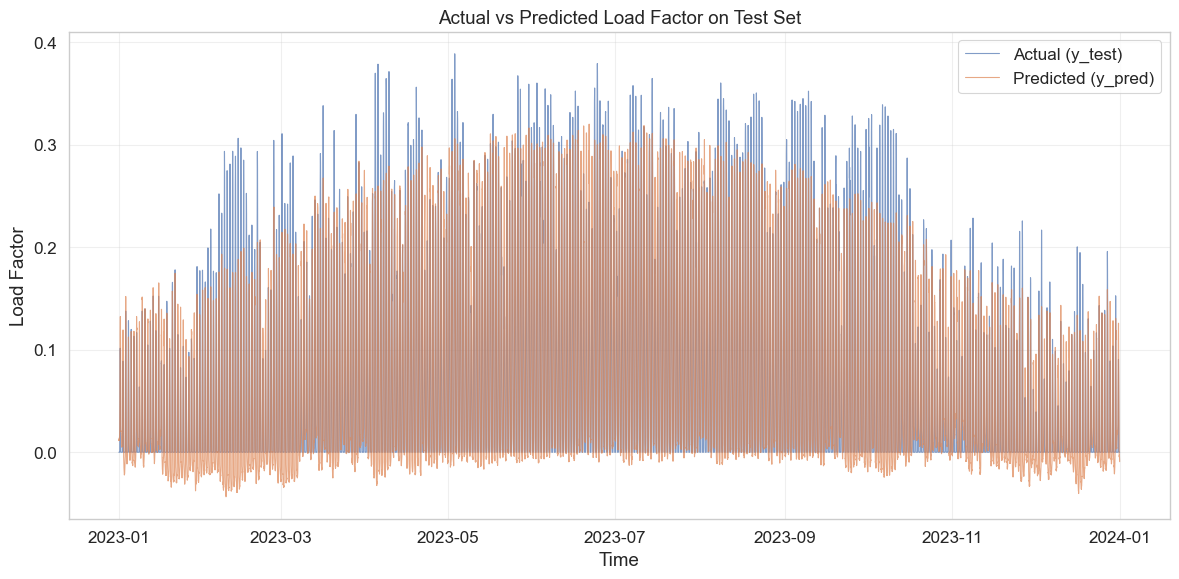

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual (y_test)', alpha=0.7, linewidth=0.8)
plt.plot(y_test.index, y_pred, label='Predicted (y_pred)', alpha=0.7, linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Load Factor')
plt.title('Actual vs Predicted Load Factor on Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Xgboost

In [77]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Définition du modèle
# Les hyperparamètres ci-dessous sont des standards de départ
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror', # Pour une régression
    n_estimators=1000,            # Nombre d'arbres (cycles de correction)
    learning_rate=0.05,           # Vitesse d'apprentissage (eta)
    max_depth=6,                  # Profondeur des arbres (Complexité)
    subsample=0.8,                # Fraction des données utilisées par arbre (évite l'overfitting)
    colsample_bytree=0.8,         # Fraction des colonnes utilisées par arbre
    early_stopping_rounds=50,     # Arrête si ça ne s'améliore plus après 50 arbres
    n_jobs=-1,                    # Utilise tous les coeurs du CPU
    random_state=42
)

# 2. Entraînement
# Note : eval_set permet de surveiller l'erreur sur le test pendant l'entraînement
print("Entraînement du XGBoost en cours...")
model_xgb.fit(
    x_train, 
    y_train,
    eval_set=[(x_train, y_train), (x_test, y_test)],
    verbose=100  # Affiche le score tous les 100 arbres
)

# 3. Prédiction sur 2023
y_pred_xgb = model_xgb.predict(x_test)

# 4. Évaluation

mse = mean_squared_error(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)

print(f"\n--- Résultats XGBoost ---")
print(f"MSE : {mse:.4f}")
print(f"MAE  : {mae:.4f}")

Entraînement du XGBoost en cours...
[0]	validation_0-rmse:0.09715	validation_1-rmse:0.09621
[100]	validation_0-rmse:0.01177	validation_1-rmse:0.01425
[200]	validation_0-rmse:0.01011	validation_1-rmse:0.01397
[299]	validation_0-rmse:0.00908	validation_1-rmse:0.01397

--- Résultats XGBoost ---
MSE : 0.0002
MAE  : 0.0070


<Figure size 1000x600 with 0 Axes>

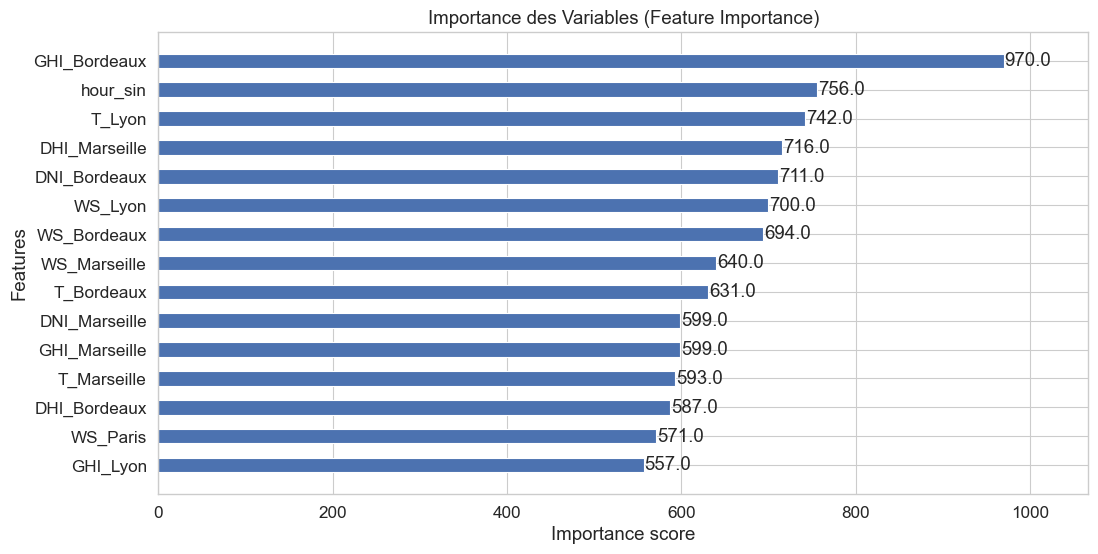

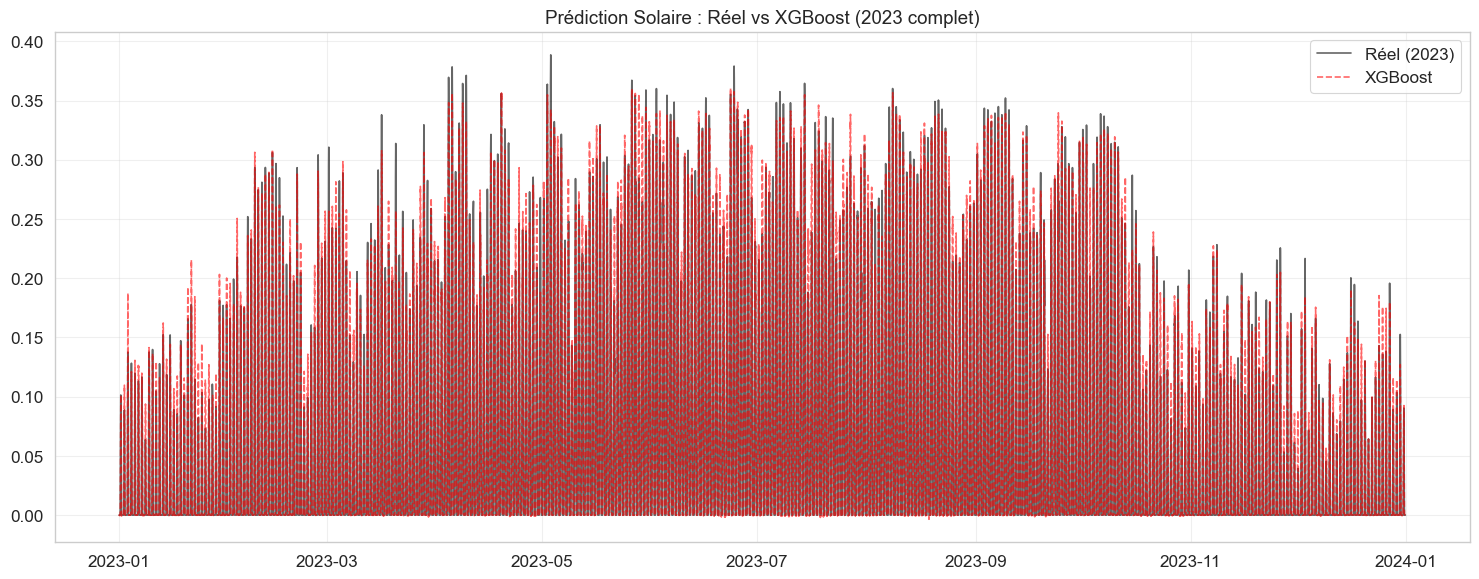

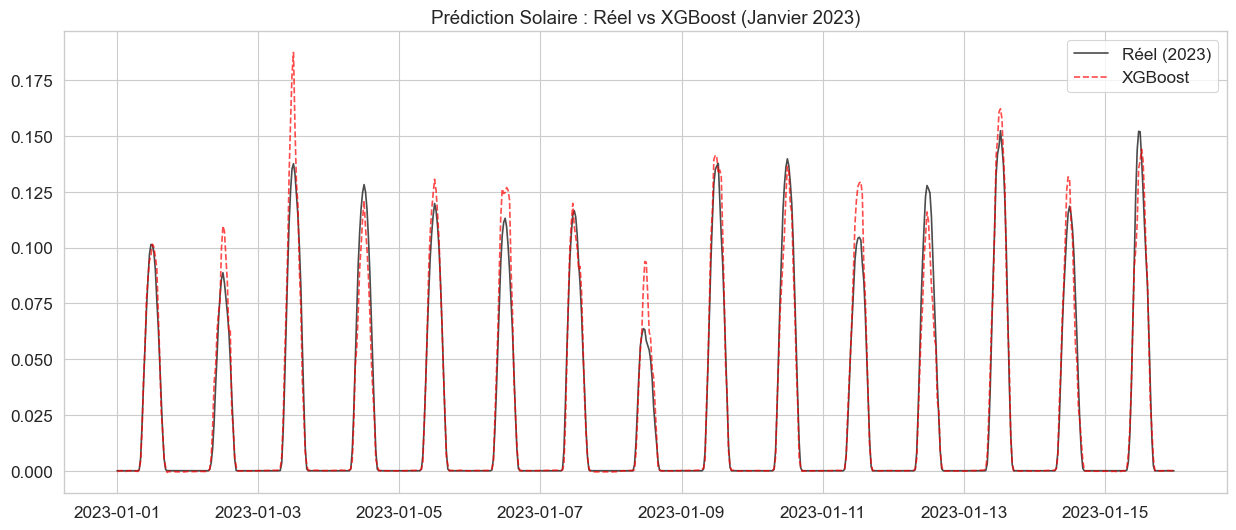

In [80]:
# Affichage de l'importance des variables
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb, max_num_features=15, height=0.5)
plt.title("Importance des Variables (Feature Importance)")
plt.show()

# Visualisation Prédiction vs Réalité sur tout le jeu de test
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test.values, label='Réel (2023)', color='black', alpha=0.6)
plt.plot(y_test.index, y_pred_xgb, label='XGBoost', color='red', alpha=0.6, linestyle='--')
plt.title("Prédiction Solaire : Réel vs XGBoost (2023 complet)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisation Prédiction vs Réalité
plt.figure(figsize=(15, 6))
# On affiche seulement le premier mois de 2023 pour y voir clair
limit = 24 * 30 
plt.plot(y_test.index[:limit], y_test.values[:limit], label='Réel (2023)', color='black', alpha=0.7)
plt.plot(y_test.index[:limit], y_pred_xgb[:limit], label='XGBoost', color='red', alpha=0.7, linestyle='--')
plt.title("Prédiction Solaire : Réel vs XGBoost (Janvier 2023)")
plt.legend()
plt.show()